<a href="https://www.kaggle.com/code/nazariyyuchnovskiy/model-cvs-tiny-example?scriptVersionId=329834645" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# PseudoAlexNetTiny training and fine-tuning

## Imports to get started

In [1]:
!pip install torchinfo
import torchinfo
import torch
import numpy as np

In [2]:
from training import (
    save_checkpoint, 
    load_checkpoint, 
    train_model_stages,
    plot_learning_curves,
    mean_and_std_for_normalization
)

from evaluation import (
    evaluate_model
)

from fine_tuning import (
    initial_freeze_unfreeze,
    second_unfreeze,
    reset_head,
    reset_head_last_fc
)

In [3]:
from model import PseudoAlexNet, DEVICE

In [4]:
from natural_images import (
    load_dataset, 
    stratified_three_way_split,
    visualize_dataset_distribution,
    StochasticCutMixDataLoader
)

from screen_images import (
    CustomEnricoDataset,
    plot_image_list
)

from maximization_core_logic import (
    visualization_process,
    compile_layer_videos
)

## Preparation of the data Caltech101(natural images)

In [5]:
from torchvision.transforms import v2

batch_size = 128

transforms = v2.Compose([
    v2.Resize((200,300)),
    v2.RGB(),
    v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)]),
    v2.Normalize(mean=[np.float32(0.5462479), np.float32(0.52917147), np.float32(0.50259775)], std=[np.float32(0.30450362), np.float32(0.29856417), np.float32(0.30875134)], inplace=False)
])

transforms_augmented_list = [
    v2.Compose([
        v2.RandomHorizontalFlip(p=0.5),
        v2.RandomResizedCrop(size=(200,300),
                         scale=(0.4,1.0))
        
    ]),
    v2.Compose([
        v2.RandomHorizontalFlip(p=0.5),
        v2.ColorJitter(),
    ]),
    v2.RandomErasing(p=1)
]

nat_images = load_dataset(data_augmented=True, transforms_original=transforms, transforms_augmented_list=transforms_augmented_list)

100%|██████████| 137M/137M [00:03<00:00, 39.3MB/s]


In [6]:
nat_images_train, nat_images_val, nat_images_test = stratified_three_way_split(dataset=nat_images, train_ratio=0.7, 
                                                                             val_ratio=0.15, test_ratio=0.15, random_state=317)

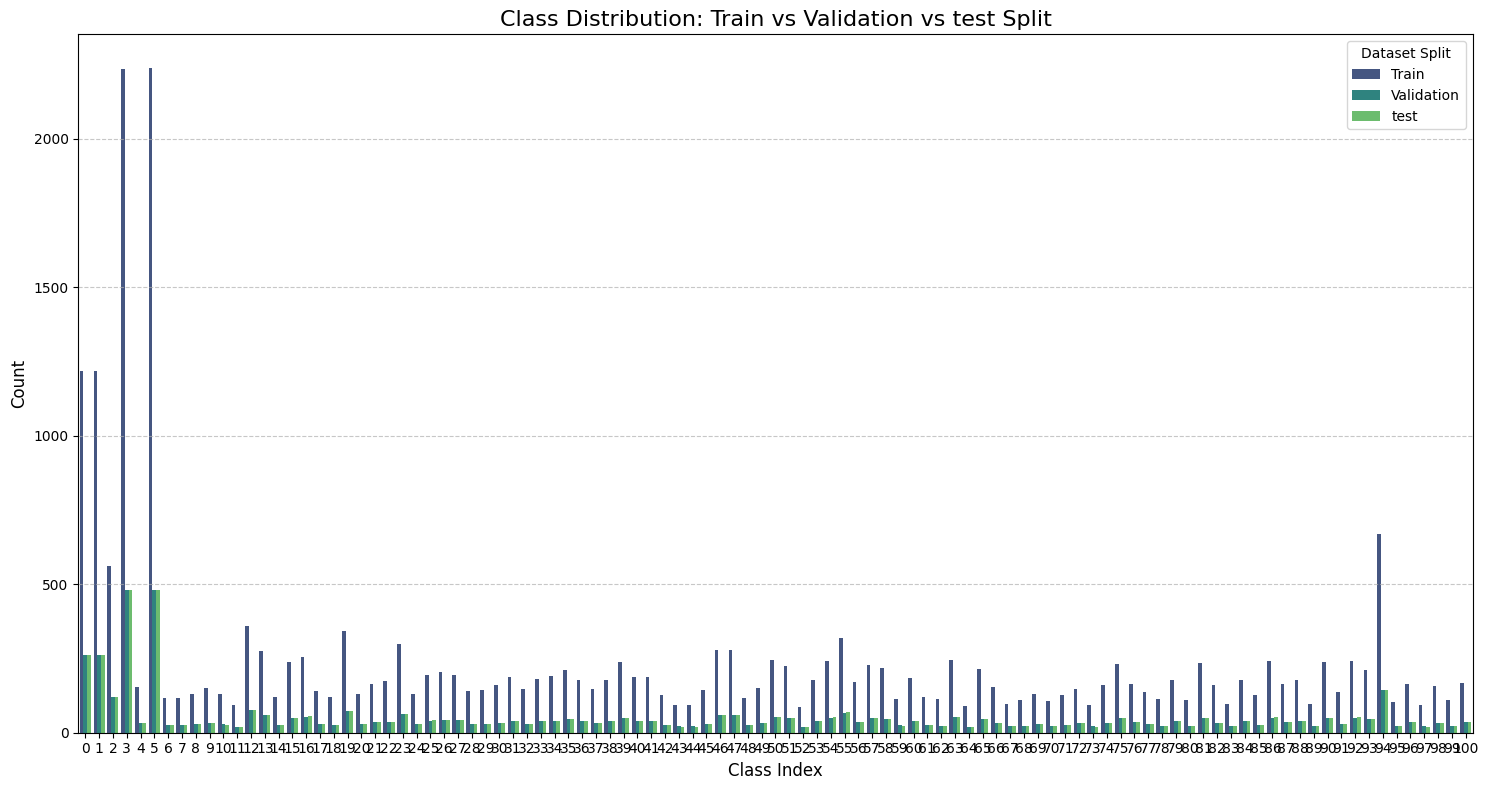

Total Training Samples:   24295 (70.0%)
Total Validation Samples: 5206 (15.0%)
Total test Samples:       5207 (15.0%)
Total Combined Samples:   34708


In [7]:
visualize_dataset_distribution(train_ds=nat_images_train, val_ds=nat_images_val, test_ds=nat_images_test)

In [8]:
nat_train_loader = torch.utils.data.DataLoader(nat_images_train, batch_size=batch_size, shuffle=True, num_workers=3)
wrapped_nat_train_loader = StochasticCutMixDataLoader(
    nat_train_loader, num_classes=101, p=0.5
)

nat_val_loader = torch.utils.data.DataLoader(nat_images_val, batch_size=batch_size, shuffle=False, num_workers=3)
nat_test_loader = torch.utils.data.DataLoader(nat_images_test, batch_size=batch_size, shuffle=False, num_workers=3)

## Training the model on Caltech101

In [9]:
import torch.optim as optim
import torch.nn as nn
MAX_NAT_EPOCHS = 40

model = PseudoAlexNet(tiny_factor=3,p=0) # with dropout and with LeakyReLU
print(torchinfo.summary(model))
model = model.to(DEVICE)
    
loss_fn = nn.NLLLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-3, eps=1e-5, weight_decay=1e-3)

val_loss_list_nat = []
train_loss_list_nat = []

Layer (type:depth-idx)                   Param #
PseudoAlexNet                            --
├─Sequential: 1-1                        --
│    └─ConvBN2d: 2-1                     --
│    │    └─Conv2d: 3-1                  304
│    │    └─BatchNorm2d: 3-2             8
│    └─ConvBN2d: 2-2                     --
│    │    └─Conv2d: 3-3                  185
│    │    └─BatchNorm2d: 3-4             10
│    └─MaxPool2d: 2-3                    --
│    └─ConvBN2d: 2-4                     --
│    │    └─Conv2d: 3-5                  368
│    │    └─BatchNorm2d: 3-6             16
│    └─ConvBN2d: 2-5                     --
│    │    └─Conv2d: 3-7                  730
│    │    └─BatchNorm2d: 3-8             20
│    └─MaxPool2d: 2-6                    --
├─Sequential: 1-2                        --
│    └─Dropout: 2-7                      --
│    └─Linear: 2-8                       2,368,256
│    └─BatchNorm1d: 2-9                  512
│    └─LeakyReLU: 2-10                   --
│    └─Dropout: 

In [10]:
train_loss_list_nat, val_loss_list_nat = train_model_stages(model=model, train_loader=wrapped_nat_train_loader, 
                                                            val_loader=nat_val_loader, optimizer=optimizer, 
                                                            loss_fn=loss_fn, device=DEVICE, max_epochs=MAX_NAT_EPOCHS,
                                                            stage_name="nat_images")

evaluate_model(model, nat_test_loader, loss_fn, DEVICE)

=== Training on the nat_images ===
Starting training of the nat_images in 40 epochs.
 nat_images training epoch 1/40...
Train Epoch: 1 [0/24320 (0%)]	Loss: 5.067344
Train Epoch: 1 [384/24320 (2%)]	Loss: 3.785439
Train Epoch: 1 [768/24320 (3%)]	Loss: 3.832101
Train Epoch: 1 [1152/24320 (5%)]	Loss: 3.555388
Train Epoch: 1 [1536/24320 (6%)]	Loss: 4.022245
Train Epoch: 1 [1920/24320 (8%)]	Loss: 3.205923
Train Epoch: 1 [2304/24320 (9%)]	Loss: 3.140087
Train Epoch: 1 [2688/24320 (11%)]	Loss: 3.282338
Train Epoch: 1 [3072/24320 (13%)]	Loss: 3.716307
Train Epoch: 1 [3456/24320 (14%)]	Loss: 3.181680
Train Epoch: 1 [3840/24320 (16%)]	Loss: 3.053934
Train Epoch: 1 [4224/24320 (17%)]	Loss: 3.662479
Train Epoch: 1 [4608/24320 (19%)]	Loss: 2.823958
Train Epoch: 1 [4992/24320 (21%)]	Loss: 3.195502
Train Epoch: 1 [5376/24320 (22%)]	Loss: 3.389132
Train Epoch: 1 [5760/24320 (24%)]	Loss: 3.293668
Train Epoch: 1 [6144/24320 (25%)]	Loss: 3.278662
Train Epoch: 1 [6528/24320 (27%)]	Loss: 2.951061
Train Epoc

(0.7428812798930378, 0.823698866909929)

## Plotting training and validation test losses

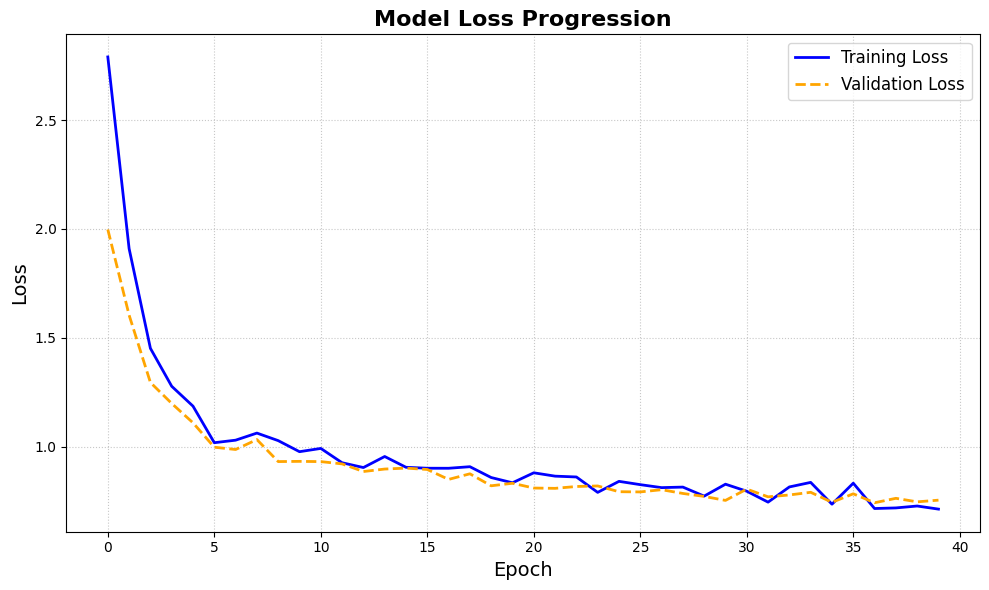

In [11]:
plot_learning_curves(train_losses=train_loss_list_nat,val_losses=val_loss_list_nat)

## Preparation of the data Enrico(screen images) - popular classes only

### 1. Defining the transformations and per class transformations for the classes that are underrepresented

In [12]:
from torchvision.transforms import v2
non_identity_perms = [
    [0, 2, 1], # R-B-G
    [1, 0, 2], # G-R-B
    [1, 2, 0], # G-B-R
    [2, 0, 1], # B-R-G
    [2, 1, 0]  # B-G-R
]

forced_channel_shuffle = v2.Lambda(
    lambda x: x[random.choice(non_identity_perms), :, :]
)

rare_class_aug = v2.Compose([
    v2.RandomPerspective(distortion_scale=0.2, p=0.5),
    v2.RandomAffine(degrees=5, translate=(0.1, 0.1)),
])


fatigue_aug = v2.Compose([
    v2.GaussianBlur(kernel_size=5, sigma=(0.1, 2.0)),
])


augmentations = {
    "dialer": [v2.RandomHorizontalFlip(p=0.5)],
    "camera": [v2.RandomAdjustSharpness(sharpness_factor=2)],
    "maps": [v2.RandomInvert(p=0.2)], 
}
augmentations = {}

universal_base = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.uint8, scale=True),
    v2.Resize(size=(180, 320)),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[np.float32(0.82380676), np.float32(0.7051618), np.float32(0.77451277)], std=[np.float32(0.23556963), np.float32(0.28753757), np.float32(0.1945423)], inplace=False)
])

### 2. Generating training and val dataset

In [13]:
allowed_classes = ["Bare", "Form", "Gallery", "List", "Login", "Menu", "Tutorial"]# the categories which have over 70 samples

allowed_classes = [s.lower() for s in allowed_classes]

small_screen_train_dataset, small_screen_val_dataset, small_screen_test_dataset = CustomEnricoDataset.create_splits(
    root="/kaggle/input/datasets/nazariyyuchnovskiy/enricoscreenshotsandwireframes",
    seed=317,
    use_wireframes=True,
    transform=universal_base,
    transform_to_class=augmentations,
    augment_for_each=[],
    allowed_classes=allowed_classes
)

Small example of transformations

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.15473..1.1590652].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.8322031..1.1590652].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.15473..1.1590652].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.28184..1.1590652].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.15473..1.1590652].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.28184..1.1590652].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.2651932..1.15906

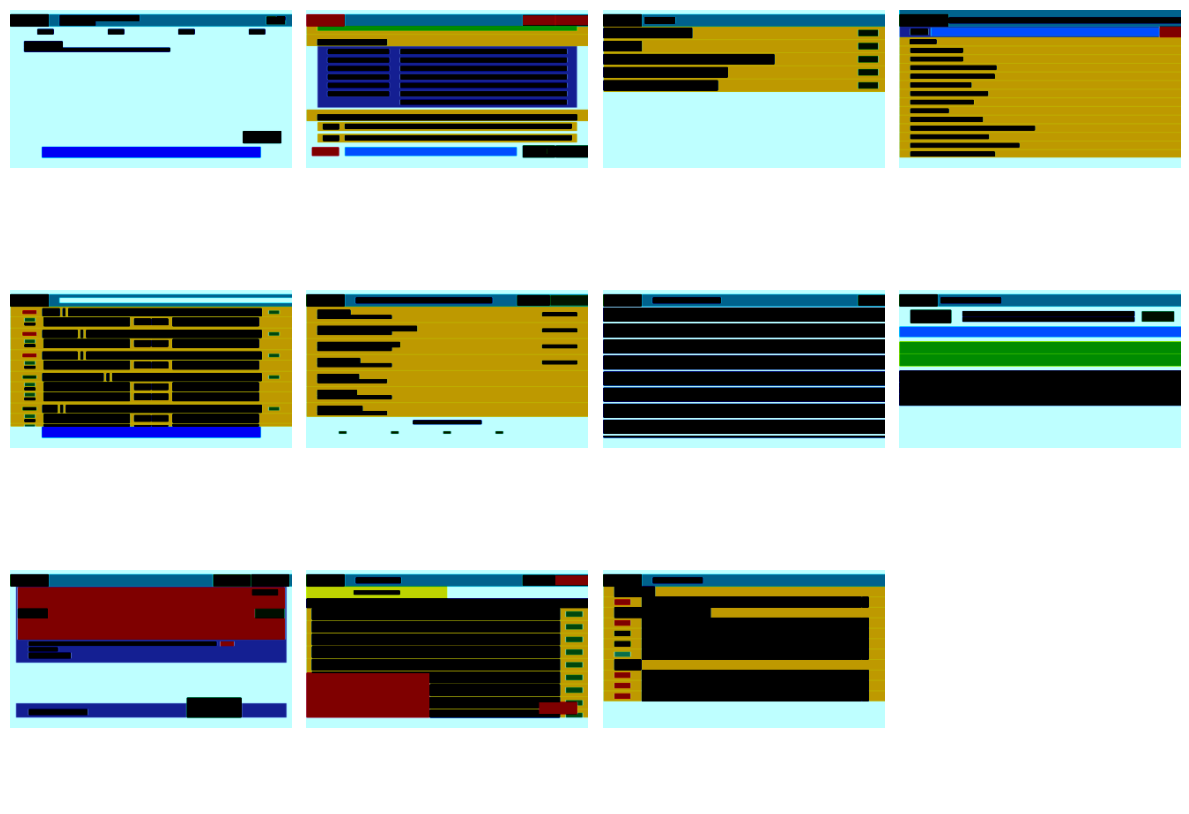

In [14]:
images = small_screen_train_dataset.get_by_label(label="list", num_samples=10)

plot_image_list(images)

In [15]:
batch_size = 128
small_screen_train_loader = torch.utils.data.DataLoader(small_screen_train_dataset, batch_size=batch_size, shuffle=True, pin_memory=True, num_workers=3)
small_screen_val_loader = torch.utils.data.DataLoader(small_screen_val_dataset, batch_size=batch_size, shuffle=False, pin_memory=True, num_workers=3)
small_screen_test_loader = torch.utils.data.DataLoader(small_screen_test_dataset, batch_size=batch_size, shuffle=False, pin_memory=True, num_workers=3)

## Preparation of the model for fine-tuning

### 1. Training on classes with >= 70 only.

Loading the checkpoint after the initial training

In [16]:
model = PseudoAlexNet(tiny_factor=3,p=0)
print(torchinfo.summary(model))

Layer (type:depth-idx)                   Param #
PseudoAlexNet                            --
├─Sequential: 1-1                        --
│    └─ConvBN2d: 2-1                     --
│    │    └─Conv2d: 3-1                  304
│    │    └─BatchNorm2d: 3-2             8
│    └─ConvBN2d: 2-2                     --
│    │    └─Conv2d: 3-3                  185
│    │    └─BatchNorm2d: 3-4             10
│    └─MaxPool2d: 2-3                    --
│    └─ConvBN2d: 2-4                     --
│    │    └─Conv2d: 3-5                  368
│    │    └─BatchNorm2d: 3-6             16
│    └─ConvBN2d: 2-5                     --
│    │    └─Conv2d: 3-7                  730
│    │    └─BatchNorm2d: 3-8             20
│    └─MaxPool2d: 2-6                    --
├─Sequential: 1-2                        --
│    └─Dropout: 2-7                      --
│    └─Linear: 2-8                       2,368,256
│    └─BatchNorm1d: 2-9                  512
│    └─LeakyReLU: 2-10                   --
│    └─Dropout: 

Adapting a model to the new classification task

### 2. Preparation of the parameters for fine-tuning on allowed classes

In [17]:
import torch.optim as optim
import torch.nn as nn
MAX_WARMUP_EPOCHS = 5
MAX_DRIFT_EPOCHS = 10
SEED = 317


reset_head(model, input_features=int((1.0/model.tiny_factor)*32)*40*22, output_features=len(allowed_classes))
model = model.to(DEVICE)

loss_fn = nn.NLLLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-3, eps=1e-5, weight_decay=1e-3)

val_loss_list_warmup_1 = []
train_loss_list_warmup_1 = []

val_loss_list_drift_1 = []
train_loss_list_drift_1 = []

### 3. Stage-1 of fine-tuning on the allowed classes

In [18]:
initial_freeze_unfreeze(model=model)

train_loss_list_warmup_1, val_loss_list_warmup_1 = train_model_stages(model=model, train_loader=small_screen_train_loader, 
                                                            val_loader=small_screen_val_loader, optimizer=optimizer, 
                                                            loss_fn=loss_fn, device=DEVICE, max_epochs=MAX_WARMUP_EPOCHS,
                                                            stage_name="warmup_1", bn_eval=True)

=== Training on the warmup_1 ===
Starting training of the warmup_1 in 5 epochs.
 warmup_1 training epoch 1/5...
Train Epoch: 1 [0/768 (0%)]	Loss: 1.970436
Train Epoch: 1 [384/768 (50%)]	Loss: 4.608599
--- Epoch 1 Training Metrics ---
Average Train Loss: 3.409585

--- Epoch 1 Evaluation ---
Validation set: Average Loss: 2.020513, Accuracy: 26.71%

Total time of epoch 1 is 9.70s

 warmup_1 training epoch 2/5...
Train Epoch: 2 [0/768 (0%)]	Loss: 2.134353
Train Epoch: 2 [384/768 (50%)]	Loss: 2.207380
--- Epoch 2 Training Metrics ---
Average Train Loss: 1.987768

--- Epoch 2 Evaluation ---
Validation set: Average Loss: 1.878123, Accuracy: 36.99%

Total time of epoch 2 is 6.68s

 warmup_1 training epoch 3/5...
Train Epoch: 3 [0/768 (0%)]	Loss: 1.422006
Train Epoch: 3 [384/768 (50%)]	Loss: 1.410437
--- Epoch 3 Training Metrics ---
Average Train Loss: 1.470454

--- Epoch 3 Evaluation ---
Validation set: Average Loss: 1.543177, Accuracy: 41.78%

Total time of epoch 3 is 6.50s

 warmup_1 trainin

### 4. Stage-2 of fine-tuning on allowed classes

In [19]:
second_unfreeze(model=model)

for param_group in optimizer.param_groups:
    param_group['lr'] = 1e-3
    
train_loss_list_drift_1, val_loss_list_drift_1 = train_model_stages(model=model, train_loader=small_screen_train_loader, 
                                                            val_loader=small_screen_val_loader, optimizer=optimizer, 
                                                            loss_fn=loss_fn, device=DEVICE, max_epochs=MAX_DRIFT_EPOCHS,
                                                            stage_name="drift_1", bn_eval=True)
evaluate_model(model, small_screen_test_loader, loss_fn, DEVICE)

=== Training on the drift_1 ===
Starting training of the drift_1 in 10 epochs.
 drift_1 training epoch 1/10...
Train Epoch: 1 [0/768 (0%)]	Loss: 1.018374
Train Epoch: 1 [384/768 (50%)]	Loss: 1.226318
--- Epoch 1 Training Metrics ---
Average Train Loss: 1.103508

--- Epoch 1 Evaluation ---
Validation set: Average Loss: 1.527345, Accuracy: 51.37%

Total time of epoch 1 is 6.74s

 drift_1 training epoch 2/10...
Train Epoch: 2 [0/768 (0%)]	Loss: 0.846606
Train Epoch: 2 [384/768 (50%)]	Loss: 1.026203
--- Epoch 2 Training Metrics ---
Average Train Loss: 0.973774

--- Epoch 2 Evaluation ---
Validation set: Average Loss: 1.364830, Accuracy: 49.32%

Total time of epoch 2 is 6.57s

 drift_1 training epoch 3/10...
Train Epoch: 3 [0/768 (0%)]	Loss: 0.897632
Train Epoch: 3 [384/768 (50%)]	Loss: 0.961262
--- Epoch 3 Training Metrics ---
Average Train Loss: 0.839688

--- Epoch 3 Evaluation ---
Validation set: Average Loss: 1.358922, Accuracy: 56.85%

Total time of epoch 3 is 6.60s

 drift_1 training 

(1.514271080493927, 0.5753424657534246)

### 5. Regenerating the train/val/test split for all classes

In [20]:
universal_base = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.uint8, scale=True),
    v2.Resize(size=(180, 320)),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[np.float32(0.8120752), np.float32(0.69213367), np.float32(0.76717395)], std=[np.float32(0.27568495), np.float32(0.35437098), np.float32(0.24276732)], inplace=False)
])

SEED=317
full_screen_train_dataset, full_screen_val_dataset, full_screen_test_dataset = CustomEnricoDataset.create_splits(
    root="/kaggle/input/datasets/nazariyyuchnovskiy/enricoscreenshotsandwireframes",
    seed=SEED,
    use_wireframes=True,
    transform=universal_base,
    augment_for_each=[],
    transform_to_class={},
    allowed_classes=None
)

In [21]:
batch_size = 128
full_screen_train_loader = torch.utils.data.DataLoader(full_screen_train_dataset, batch_size=batch_size, shuffle=False, pin_memory=True, num_workers=3)
full_screen_val_loader = torch.utils.data.DataLoader(full_screen_val_dataset, batch_size=batch_size, shuffle=False, pin_memory=True, num_workers=3)
full_screen_test_loader = torch.utils.data.DataLoader(full_screen_test_dataset, batch_size=batch_size, shuffle=False, pin_memory=True, num_workers=3)

reset_head_last_fc(model, output_features=20)

### 6. Preparation of the parameters for fine-tuning

In [22]:
MAX_WARMUP_EPOCHS = 10
MAX_DRIFT_EPOCHS = 40
SEED = 317

loss_fn = nn.NLLLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-3, eps=1e-5, weight_decay=1e-3)
model = model.to(DEVICE)
val_loss_list_warmup_2 = []
train_loss_list_warmup_2 = []

val_loss_list_drift_2 = []
train_loss_list_drift_2 = []

### 7. Stage 1 of full classes fine-tuning

In [23]:
initial_freeze_unfreeze(model=model)

train_loss_list_warmup_2, val_loss_list_warmup_2 = train_model_stages(model=model, train_loader=full_screen_train_loader, 
                                                            val_loader=full_screen_val_loader, optimizer=optimizer, 
                                                            loss_fn=loss_fn, device=DEVICE, max_epochs=MAX_WARMUP_EPOCHS,
                                                            stage_name="warmup_2", bn_eval=True)

=== Training on the warmup_2 ===
Starting training of the warmup_2 in 10 epochs.
 warmup_2 training epoch 1/10...
Train Epoch: 1 [0/1024 (0%)]	Loss: 2.992810
Train Epoch: 1 [384/1024 (38%)]	Loss: 5.572819
Train Epoch: 1 [768/1024 (75%)]	Loss: 4.208666
--- Epoch 1 Training Metrics ---
Average Train Loss: 5.014321

--- Epoch 1 Evaluation ---
Validation set: Average Loss: 3.119869, Accuracy: 12.79%

Total time of epoch 1 is 10.11s

 warmup_2 training epoch 2/10...
Train Epoch: 2 [0/1024 (0%)]	Loss: 3.089667
Train Epoch: 2 [384/1024 (38%)]	Loss: 2.827278
Train Epoch: 2 [768/1024 (75%)]	Loss: 2.453958
--- Epoch 2 Training Metrics ---
Average Train Loss: 2.643346

--- Epoch 2 Evaluation ---
Validation set: Average Loss: 2.503774, Accuracy: 27.85%

Total time of epoch 2 is 9.03s

 warmup_2 training epoch 3/10...
Train Epoch: 3 [0/1024 (0%)]	Loss: 2.283088
Train Epoch: 3 [384/1024 (38%)]	Loss: 2.483305
Train Epoch: 3 [768/1024 (75%)]	Loss: 2.081366
--- Epoch 3 Training Metrics ---
Average Trai

In [24]:
second_unfreeze(model=model)

for param_group in optimizer.param_groups:
    param_group['lr'] = 1e-3
    
train_loss_list_drift_2, val_loss_list_drift_2 = train_model_stages(model=model, train_loader=full_screen_train_loader, 
                                                            val_loader=full_screen_val_loader, optimizer=optimizer, 
                                                            loss_fn=loss_fn, device=DEVICE, max_epochs=MAX_DRIFT_EPOCHS,
                                                            stage_name="drift_2", bn_eval=True)

evaluate_model(model, full_screen_test_loader, loss_fn, DEVICE)

=== Training on the drift_2 ===
Starting training of the drift_2 in 40 epochs.
 drift_2 training epoch 1/40...
Train Epoch: 1 [0/1024 (0%)]	Loss: 0.929508
Train Epoch: 1 [384/1024 (38%)]	Loss: 1.120582
Train Epoch: 1 [768/1024 (75%)]	Loss: 0.844688
--- Epoch 1 Training Metrics ---
Average Train Loss: 0.900316

--- Epoch 1 Evaluation ---
Validation set: Average Loss: 2.289685, Accuracy: 43.84%

Total time of epoch 1 is 8.97s

 drift_2 training epoch 2/40...
Train Epoch: 2 [0/1024 (0%)]	Loss: 0.775560
Train Epoch: 2 [384/1024 (38%)]	Loss: 0.943236
Train Epoch: 2 [768/1024 (75%)]	Loss: 0.667731
--- Epoch 2 Training Metrics ---
Average Train Loss: 0.731898

--- Epoch 2 Evaluation ---
Validation set: Average Loss: 2.491298, Accuracy: 42.47%

Total time of epoch 2 is 8.83s

 drift_2 training epoch 3/40...
Train Epoch: 3 [0/1024 (0%)]	Loss: 0.670244
Train Epoch: 3 [384/1024 (38%)]	Loss: 0.727687
Train Epoch: 3 [768/1024 (75%)]	Loss: 0.473655
--- Epoch 3 Training Metrics ---
Average Train Loss

(3.80219042301178, 0.365296803652968)

### Plotting final train/test split

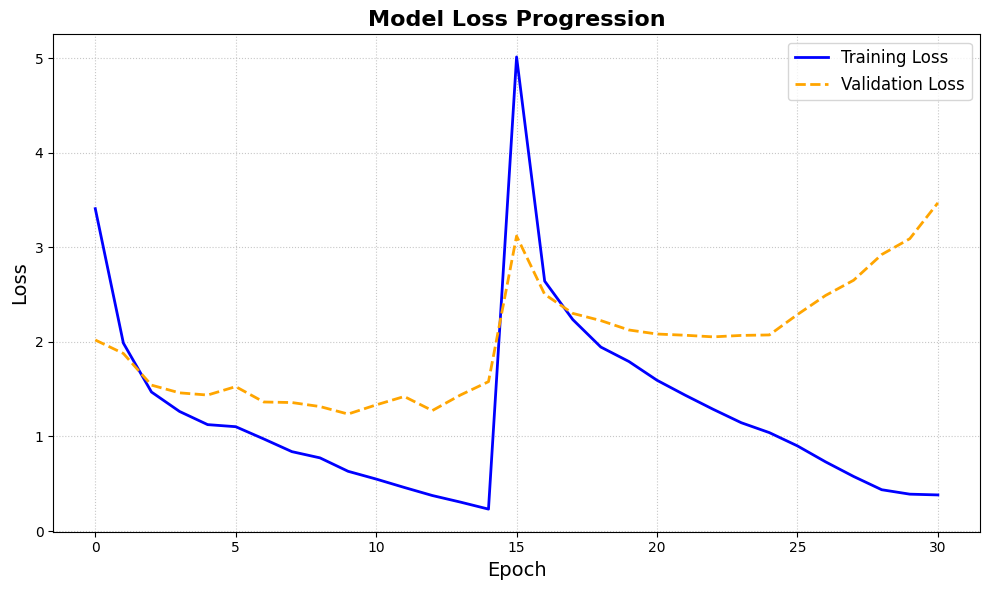

In [25]:
train_loss_list = train_loss_list_warmup_1 + train_loss_list_drift_1 + train_loss_list_warmup_2 + train_loss_list_drift_2
val_loss_list = val_loss_list_warmup_1 + val_loss_list_drift_1 + val_loss_list_warmup_2 + val_loss_list_drift_2

plot_learning_curves(train_losses=train_loss_list,val_losses=val_loss_list)

## Training the PseudoAlexNetTiny on the Enrico for comparison

In [26]:
import torch.optim
MAX_SCREEN_EPOCHS = 40
SEED = 317

universal_base = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.uint8, scale=True),
    v2.Resize(size=(180, 320)),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[np.float32(0.8120752), np.float32(0.69213367), np.float32(0.76717395)], std=[np.float32(0.27568495), np.float32(0.35437098), np.float32(0.24276732)], inplace=False)
])


In [27]:
full_screen_train_dataset, full_screen_val_dataset, full_screen_test_dataset = CustomEnricoDataset.create_splits(
    root="/kaggle/input/datasets/nazariyyuchnovskiy/enricoscreenshotsandwireframes",
    seed=SEED,
    use_wireframes=True,
    transform=universal_base,
    augment_for_each=[],
    transform_to_class={},
    allowed_classes=None
)

batch_size = 128
full_screen_train_loader = torch.utils.data.DataLoader(full_screen_train_dataset, batch_size=batch_size, shuffle=False, pin_memory=True, num_workers=3)
full_screen_val_loader = torch.utils.data.DataLoader(full_screen_val_dataset, batch_size=batch_size, shuffle=False, pin_memory=True, num_workers=3)
full_screen_test_loader = torch.utils.data.DataLoader(full_screen_test_dataset, batch_size=batch_size, shuffle=False, pin_memory=True, num_workers=3)

model = PseudoAlexNet(tiny_factor=3, p=0) # with dropout and with LeakyReLU

fc_last_in_features = model.classifier[-1].in_features
model.classifier[1] = nn.Linear(in_features=10*40*22, out_features=fc_last_in_features)
model.classifier[-1] = nn.Linear(in_features=fc_last_in_features, out_features=20) # exactly so much classes are in Enrico

loss_fn = nn.NLLLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-3, eps=1e-5, weight_decay=1e-3)

val_loss_list_screen = []
train_loss_list_screen = []

model = model.to(DEVICE)
print(torchinfo.summary(model))

Layer (type:depth-idx)                   Param #
PseudoAlexNet                            --
├─Sequential: 1-1                        --
│    └─ConvBN2d: 2-1                     --
│    │    └─Conv2d: 3-1                  304
│    │    └─BatchNorm2d: 3-2             8
│    └─ConvBN2d: 2-2                     --
│    │    └─Conv2d: 3-3                  185
│    │    └─BatchNorm2d: 3-4             10
│    └─MaxPool2d: 2-3                    --
│    └─ConvBN2d: 2-4                     --
│    │    └─Conv2d: 3-5                  368
│    │    └─BatchNorm2d: 3-6             16
│    └─ConvBN2d: 2-5                     --
│    │    └─Conv2d: 3-7                  730
│    │    └─BatchNorm2d: 3-8             20
│    └─MaxPool2d: 2-6                    --
├─Sequential: 1-2                        --
│    └─Dropout: 2-7                      --
│    └─Linear: 2-8                       2,253,056
│    └─BatchNorm1d: 2-9                  512
│    └─LeakyReLU: 2-10                   --
│    └─Dropout: 

=== Training on the screen ===
Starting training of the screen in 40 epochs.
 screen training epoch 1/40...
Train Epoch: 1 [0/1024 (0%)]	Loss: 3.045014
Train Epoch: 1 [384/1024 (38%)]	Loss: 2.974836
Train Epoch: 1 [768/1024 (75%)]	Loss: 2.653054
--- Epoch 1 Training Metrics ---
Average Train Loss: 3.005579

--- Epoch 1 Evaluation ---
Validation set: Average Loss: 2.585039, Accuracy: 26.48%

Total time of epoch 1 is 8.87s

 screen training epoch 2/40...
Train Epoch: 2 [0/1024 (0%)]	Loss: 2.414845
Train Epoch: 2 [384/1024 (38%)]	Loss: 2.520016
Train Epoch: 2 [768/1024 (75%)]	Loss: 2.264358
--- Epoch 2 Training Metrics ---
Average Train Loss: 2.374194

--- Epoch 2 Evaluation ---
Validation set: Average Loss: 2.371374, Accuracy: 29.68%

Total time of epoch 2 is 9.04s

 screen training epoch 3/40...
Train Epoch: 3 [0/1024 (0%)]	Loss: 2.083417
Train Epoch: 3 [384/1024 (38%)]	Loss: 2.281224
Train Epoch: 3 [768/1024 (75%)]	Loss: 2.067484
--- Epoch 3 Training Metrics ---
Average Train Loss: 2.1

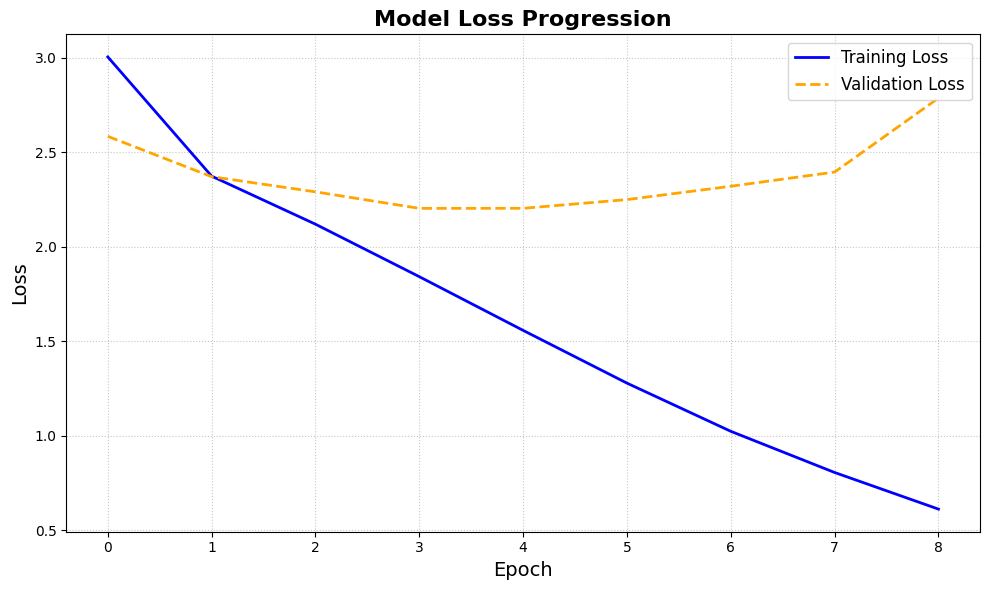

In [28]:
train_loss_list_screen, val_loss_list_screen = train_model_stages(model=model, train_loader=full_screen_train_loader, 
                                                            val_loader=full_screen_val_loader, optimizer=optimizer, 
                                                            loss_fn=loss_fn, device=DEVICE, max_epochs=MAX_SCREEN_EPOCHS,
                                                            stage_name="screen", bn_eval=True)


evaluate_model(model, full_screen_test_loader, loss_fn, DEVICE)

plot_learning_curves(train_losses=train_loss_list_screen,val_losses=val_loss_list_screen)